# Homework 1

**Coverage:** Lectures 1–4  
**Due:** Sunday, August 30, 2026, 11:59 p.m. ET  
**Total:** 100 points

## Instructions

- Complete this notebook in Google Colab.
- Problem 1 is a manual mathematics problem. Show every important step in
  Markdown/LaTeX, or insert one clearly legible image of your handwritten work.
  Code may check arithmetic only after the derivation is complete.
- Problem 2 is a guided scientific-computing study. Do not delete supplied
  setup or helper cells.
- Your submitted notebook must run from beginning to end in a fresh Colab
  runtime without Google Drive, absolute paths, or additional package
  installation.
- Label plots and include units. Report numerical answers to at least four
  significant digits unless a question states otherwise.

The course material needed for this assignment is collected here:

- [Probability rules and reverse conditioning](https://predictivesciencelab.github.io/data-analytics-se/lecture02/reading-02.html)
- [Continuous random variables, CDFs, PDFs, and expectations](https://predictivesciencelab.github.io/data-analytics-se/lecture04/reading-04.html)
- [The uniform distribution](https://predictivesciencelab.github.io/data-analytics-se/lecture04/hands-on-04.1.html)
- [The Gaussian distribution and its quantiles](https://predictivesciencelab.github.io/data-analytics-se/lecture04/hands-on-04.2.html)

## Student details

- **First name:** Harishteja
- **Last name:** Peddi
- **Purdue email:** peddih@purdue.edu

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
import logging

import numpy as np
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
import matplotlib.pyplot as plt
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=6, suppress=True)

## Problem 1 — Diagnosing a pump from a vibration alarm (25 points)

A centrifugal pump operates under a fixed regime. Its unknown condition is
modeled as exactly one of three states:

- $H$: the pump is healthy;
- $M$: the pump is misaligned;
- $C$: the pump is cavitating.

The three states are mutually exclusive and exhaustive under this simplified
model. Historical operating records give

$$
P(H)=0.96, \qquad P(M)=0.03, \qquad P(C)=0.01.
$$

A vibration monitor returns either an alarm $A$ or no alarm $A^c$. Its
alarm probabilities are

$$
P(A\mid H)=0.05, \qquad
P(A\mid M)=0.80, \qquad
P(A\mid C)=0.95.
$$

The probability $P(A\mid H)$ is the **false-alarm probability**: the monitor
alarms even though the pump is healthy. The corresponding quantity
$P(A^c\mid H)=1-P(A\mid H)$ is the monitor's **specificity**. A probability
conditioned on an observed alarm, such as $P(M\mid A)$, is a **posterior
probability** because it describes the state of knowledge after observing the
alarm. Use the [sum and product rules](https://predictivesciencelab.github.io/data-analytics-se/lecture02/reading-02.html) throughout.

### 1.1 Joint probabilities (6 points)

Construct a table containing all six state-and-monitor outcomes. Calculate
the joint probabilities $P(A,H)$, $P(A,M)$, $P(A,C)$, $P(A^c,H)$,
$P(A^c,M)$, and $P(A^c,C)$, and verify that they sum to one. Here
$P(A,H)$ means $P(A\cap H)$.


For any state $X \in \{H, M, C\}$, the joint probability of the alarm and that state is

$$P(A, X) = P(A \mid X)\,P(X), \qquad P(A^c, X) = P(A^c \mid X)\,P(X) = \big(1-P(A\mid X)\big)P(X)$$

**Substituting the given numbers:**

$$P(A,H) = P(A\mid H)P(H) = (0.05)(0.96) = 0.0480$$

$$P(A,M) = P(A\mid M)P(M) = (0.80)(0.03) = 0.0240$$

$$P(A,C) = P(A\mid C)P(C) = (0.95)(0.01) = 0.0095$$

$$P(A^c,H) = (1-0.05)(0.96) = (0.95)(0.96) = 0.9120$$

$$P(A^c,M) = (1-0.80)(0.03) = (0.20)(0.03) = 0.0060$$

$$P(A^c,C) = (1-0.95)(0.01) = (0.05)(0.01) = 0.0005$$

**Table:**

| State $X$ | $P(X)$ | $P(A\mid X)$ | $P(A,X)$ | $P(A^c,X)$ |
|---|---|---|---|---|
| H | 0.96 | 0.05 | 0.0480 | 0.9120 |
| M | 0.03 | 0.80 | 0.0240 | 0.0060 |
| C | 0.01 | 0.95 | 0.0095 | 0.0005 |

**Verification using the sum rule.** Since $\{H,M,C\}$ partitions the sample space, the six joint outcomes $\{A,A^c\}\times\{H,M,C\}$ partition it too:

$$\sum_X \big[P(A,X)+P(A^c,X)\big] = (0.0480+0.0240+0.0095)+(0.9120+0.0060+0.0005) = 0.0815 + 0.9185 = 1.0000 \$$



### 1.2 Posterior diagnosis (8 points)

Calculate $P(H\mid A)$, $P(M\mid A)$, $P(C\mid A)$, and
$P(M\text{ or }C\mid A)$. Show the symbolic numerator and denominator before
substituting numerical values.


**Bayes' rule** --

For any state $X$, the posterior given the alarm is

$$P(X \mid A) = \frac{P(A \mid X)\,P(X)}{P(A)}$$

where the denominator, by the **sum rule**, is the total probability of an alarm across the full partition $\{H,M,C\}$:

$$P(A) = P(A\mid H)P(H) + P(A\mid M)P(M) + P(A\mid C)P(C)$$

**Fomrulation before substitution:**

$$P(H\mid A) = \frac{P(A\mid H)P(H)}{P(A\mid H)P(H)+P(A\mid M)P(M)+P(A\mid C)P(C)}$$

$$P(M\mid A) = \frac{P(A\mid M)P(M)}{P(A\mid H)P(H)+P(A\mid M)P(M)+P(A\mid C)P(C)}$$

$$P(C\mid A) = \frac{P(A\mid C)P(C)}{P(A\mid H)P(H)+P(A\mid M)P(M)+P(A\mid C)P(C)}$$

**Denominator, numerically:**

$$P(A) = 0.0480 + 0.0240 + 0.0095 = 0.0815$$

**Substituting numerators:**

$$P(H\mid A) = \frac{0.0480}{0.0815} = 0.5890$$

$$P(M\mid A) = \frac{0.0240}{0.0815} = 0.2945$$

$$P(C\mid A) = \frac{0.0095}{0.0815} = 0.1166$$

**Combined event:**

$$P(M \text{ or } C \mid A) = P(M\mid A) + P(C\mid A) = 0.2945 + 0.1166 = 0.4110$$

**Check:** $P(H\mid A)+P(M\mid A)+P(C\mid A) = 1.0000\$

### 1.3 Interpretation (4 points)

Compare the prior probability of a fault, $P(M\text{ or }C)$, with its
posterior probability after an alarm. Then explain why $H$ is still the most
probable individual state after an alarm.


**Prior probability of a fault:**

$$P(M \text{ or } C) = P(M) + P(C) = 0.03 + 0.01 = 0.04$$

**Posterior fault probability** (from 1.2):

$$P(M \text{ or } C \mid A) = 0.4110$$

**Comparison:**

 Observing a single alarm raises the probability of a fault from $4.00\%$ to $41.10\%$ — an absolute increase of about $0.371$, or roughly a $10.3\times$ relative increase. The alarm is highly informative.

**Why H is still the most probable individual state.**

 Even so, $P(H\mid A) = 0.5890$ exceeds both $P(M\mid A)=0.2945$ and $P(C\mid A)=0.1166$ individually. This is because the priors are extremely imbalanced: $P(H)=0.96 \gg P(M),P(C)$, so even a small false-alarm rate $P(A\mid H)=0.05$ produces a joint probability $P(A,H)=0.0480$ comparable to $P(A,M)=0.0240$ and larger than $P(A,C)=0.0095$.

### 1.4 Monitor design (7 points)

A redesigned monitor keeps $P(A\mid M)=0.80$ and $P(A\mid C)=0.95$, while
its false-alarm probability is $q=P(A\mid H)$. Derive the largest $q$ for
which $P(M\text{ or }C\mid A)\geq0.90$. Report the corresponding minimum
specificity, and explain the practical significance of the requirement.

Given $q = P(A\mid H)$ be the redesigned false-alarm probability, with $P(A\mid M)=0.80$ and $P(A\mid C)=0.95$ unchanged. Define

$$S \equiv P(A\mid M)P(M) + P(A\mid C)P(C)$$

By the product and sum rules,

$$P(M \text{ or } C \mid A) = \frac{P(A\mid M)P(M)+P(A\mid C)P(C)}{P(A\mid H)P(H)+P(A\mid M)P(M)+P(A\mid C)P(C)} = \frac{S}{S + qP(H)}$$

**Numerical value of $S$:**

$$S = (0.80)(0.03) + (0.95)(0.01) = 0.0240 + 0.0095 = 0.0335$$

**Imposing the requirement** $P(M\text{ or }C\mid A)\ge 0.90$:

$$\frac{S}{S+qP(H)} \ge 0.90$$

   $$ S \ge 0.90S + 0.90\,q\,P(H)$$

   $$ q \le \frac{0.10\,S}{0.90\,P(H)}$$

**Substituting numbers:**

$$q_{\max} = \frac{0.10(0.0335)}{0.90(0.96)} = \frac{0.00335}{0.864} \approx 0.003877$$

$$\boxed{q_{\max} \approx 0.003877}$$

**Minimum specificity:**

$$\text{specificity}_{\min} = 1-q_{\max} = 0.996123 \approx 99.6123\%$$

**Practical significance.** To trust a single alarm as at least $90\%$ likely to indicate a real fault, the false-alarm rate must drop from $5\%$ to under about $0.39\%$ — a more-than-tenfold improvement in specificity. This is a direct consequence of the base-rate effect: because healthy pumps ($P(H)=0.96$) vastly outnumber faulty ones, even small false-alarm rates generate a large absolute number of false positives. High confidence in a single alarm therefore demands an extremely specific monitor.

## Problem 2 — Fatigue life of an aluminum alloy (75 points)

Rectangular specimens of 6061-T6 aluminum were subjected to repeated loading
with a maximum stress of $21{,}000$ psi. The recorded quantity is the number
of cycles until rupture, measured in thousands of cycles. The 101 observations
come from the NIST fatigue-life case study and were originally reported by
Birnbaum and Saunders.

- [NIST description and complete data](https://www.itl.nist.gov/div898/handbook/eda/section4/eda4291.htm)
- [Original study](https://doi.org/10.1080/01621459.1958.10501433)

We will compare three probability models and use them to answer a replacement
question. No model is declared correct in advance.

Let $T>0$ denote fatigue life. Its cumulative distribution function (CDF) is

$$
F(t)=P(T\leq t).
$$

The **survival function** is

$$
S(t)=P(T>t)=1-F(t).
$$

Thus, $S(t)$ is the probability that a specimen has not ruptured after $t$
thousand loading cycles.

For observed fatigue lives $t_1,\ldots,t_n$, the **empirical CDF** is

$$
\widehat F_n(t)=\frac{1}{n}\sum_{i=1}^n
\mathbf{1}(t_i\leq t),
$$

where $\mathbf{1}(t_i\leq t)$ equals one when $t_i\leq t$ and zero
otherwise. Thus, $\widehat F_n(t)$ is the observed fraction that failed by
age $t$. The empirical survival function is
$\widehat S_n(t)=1-\widehat F_n(t)$.

In [22]:
# Fatigue life in thousands of cycles. The values are embedded so that the
# notebook remains reproducible if the external source is unavailable.
fatigue_life = np.array([
     370, 1016, 1235, 1419, 1567, 1820,
     706, 1018, 1238, 1420, 1578, 1868,
     716, 1020, 1252, 1420, 1594, 1881,
     746, 1055, 1258, 1450, 1602, 1890,
     785, 1085, 1262, 1452, 1604, 1893,
     797, 1102, 1269, 1475, 1608, 1895,
     844, 1102, 1270, 1478, 1630, 1910,
     855, 1108, 1290, 1481, 1642, 1923,
     858, 1115, 1293, 1485, 1674, 1940,
     886, 1120, 1300, 1502, 1730, 1945,
     886, 1134, 1310, 1505, 1750, 2023,
     930, 1140, 1313, 1513, 1750, 2100,
     960, 1199, 1315, 1522, 1763, 2130,
     988, 1200, 1330, 1522, 1768, 2215,
     990, 1200, 1355, 1530, 1781, 2268,
    1000, 1203, 1390, 1540, 1782, 2440,
    1010, 1222, 1416, 1560, 1792,
], dtype=float)


def empirical_cdf(sample, grid):
    """Evaluate the empirical CDF of a one-dimensional sample on a grid.

    Arguments:
    sample -- The observed data values.
    grid   -- The values at which to evaluate the empirical CDF.
    """
    sample = np.asarray(sample, dtype=float)
    grid = np.asarray(grid, dtype=float)
    return np.mean(sample[:, None] <= grid[None, :], axis=0)


def uniform_discrepancy(values):
    """Return the maximum vertical gap from the uniform CDF on [0, 1].

    Arguments:
    values -- The transformed observations to compare with the uniform CDF.
    """
    ordered = np.sort(np.asarray(values, dtype=float))
    n = ordered.size
    gap_above = np.arange(1, n + 1) / n - ordered
    gap_below = ordered - np.arange(n) / n
    return max(np.max(gap_above), np.max(gap_below))


print(f"Loaded {fatigue_life.size} observed fatigue lives.")

Loaded 101 observed fatigue lives.


### 2.1 Empirical reliability (10 points)

1. **Summary (2 points).** Report the number, minimum, median, and maximum of
   the observed fatigue lives.
2. **Empirical survival (5 points).** Plot the empirical survival function for
   the observed fatigue-life data. Mark every observed fatigue life along the
   horizontal axis.
3. **Interpretation (3 points).** Calculate the observed fraction that
   survived beyond one million cycles and explain why the empirical survival
   function decreases in steps.

n = 101, min = 370.0, median = 1416.0, max = 2440.0


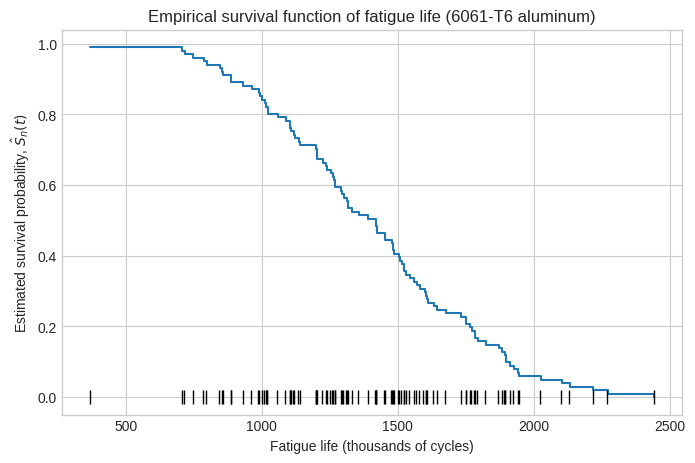

Fraction surviving beyond 1,000,000 cycles: 0.8416


In [23]:
# YOUR CODE HERE
#1. Summary

n_obs = len(fatigue_life)
t_min = np.min(fatigue_life)
t_max= np.max(fatigue_life)
t_median = np.median(fatigue_life)
print(f"n = {n_obs}, min = {t_min}, median = {t_median}, max = {t_max}")

#2. Emperical Survival


grid = np.linspace(t_min, t_max, 500)
S_hat = 1 - empirical_cdf(fatigue_life, grid)

fig, ax = plt.subplots(figsize=(8, 5))
ax.step(grid, S_hat, where="post")

ax.plot(fatigue_life, np.zeros_like(fatigue_life), "|", color="black", markersize=10)

ax.set_xlabel("Fatigue life (thousands of cycles)")
ax.set_ylabel(r"Estimated survival probability, $\hat{S}_n(t)$")
ax.set_title("Empirical survival function of fatigue life (6061-T6 aluminum)")
plt.show()

# 3.Interpretation


frac_survive_1M = np.mean(fatigue_life > 1000)

print(f"Fraction surviving beyond 1,000,000 cycles: {frac_survive_1M:.4f}")


**3.Interpretation**

The empirical survival function decreases in steps because it comes from a finite sample of 101 specimens. $\hat{S}_n(t)$ only changes at the exact cycle counts where a specimen ruptured in between failure times nothing new has happened, so the curve stays flat. With infinitely many observations these steps would shrink into a smooth curve, but with only 101 data points the staircase shape is unavoidable.

### Candidate lifetime models

The first candidate is a two-parameter
[Weibull distribution](https://en.wikipedia.org/wiki/Weibull_distribution):

$$
F_W(t)=
\begin{cases}
0, & t<0,\\[2mm]
1-\exp\!\left[-\left(\dfrac{t}{\lambda}\right)^k\right], & t\geq0,
\end{cases}
$$

where $k>0$ is a dimensionless shape parameter and $\lambda>0$ is a scale
parameter with the same units as $T$.

The second candidate is a two-parameter lognormal model. For $t$ expressed in
thousands of cycles, its CDF is

$$
F_L(t)=
\begin{cases}
0, & t\leq0,\\[2mm]
\Phi\!\left(\dfrac{\log t-\mu_L}{\sigma_L}\right), & t>0,
\end{cases}
$$

where $\log$ is the natural logarithm, $\mu_L$ is the mean of $\log T$,
$\sigma_L>0$ is its standard deviation, and $\Phi$ is the standard Gaussian
CDF introduced in [Lecture 4](https://predictivesciencelab.github.io/data-analytics-se/lecture04/hands-on-04.2.html). The quantity
$\eta=\exp(\mu_L)$ is the lognormal scale parameter and has the same units as
$T$.

The third candidate is an exponential model:

$$
F_E(t)=
\begin{cases}
0, & t<0,\\[2mm]
1-\exp\!\left(-\dfrac{t}{\beta}\right), & t\geq0,
\end{cases}
$$

where $\beta>0$ is both the scale parameter and the mean lifetime. The
exponential model is the special case $k=1$ of the Weibull model. All three
models assign probability only to nonnegative lifetimes.

The models contain unknown parameters. Assuming the observations are
independent draws from one distribution, **maximum-likelihood fitting** chooses
the parameter values under which the observed sample has the largest joint
probability density. The fitting calls below are supplied; the theory of
maximum likelihood is not assessed in this assignment. Fixing `floc=0.0`
enforces the stated nonnegative support and gives the parameterizations above.

In [24]:
weibull_shape_hat, _, weibull_scale_hat = stats.weibull_min.fit(
    fatigue_life, floc=0.0
)
lognormal_shape_hat, _, lognormal_scale_hat = stats.lognorm.fit(
    fatigue_life, floc=0.0
)
lognormal_mu_hat = np.log(lognormal_scale_hat)
_, exponential_scale_hat = stats.expon.fit(fatigue_life, floc=0.0)

weibull_model = stats.weibull_min(
    weibull_shape_hat, loc=0.0, scale=weibull_scale_hat
)
lognormal_model = stats.lognorm(
    lognormal_shape_hat, loc=0.0, scale=lognormal_scale_hat
)
exponential_model = stats.expon(loc=0.0, scale=exponential_scale_hat)

print("The three candidate models are fitted and ready for analysis.")

The three candidate models are fitted and ready for analysis.


### 2.2 Fitted models (20 points)

1. **Parameters and probabilities (8 points).** Report the fitted parameters
   with units. For each model, calculate the mean, median, and
   $P(1000<T<1800)$.
2. **Survival comparison (12 points).** Re-create the empirical-survival plot
   from Part 2.1 and overlay all three fitted survival functions. Identify any
   model that is visibly inconsistent with the data. For the Weibull and
   lognormal models, calculate the largest absolute difference in survival
   probability over 0 to 2600 thousand cycles and report approximately where
   it occurs.

=== Weibull ===
shape k = 3.9463
scale lambda = 1545.9567 (thousand cycles)
mean   = 1400.1854
median = 1408.8426
P(1000<T<1800) = 0.6744

=== Lognormal ===
sigma_L = 0.3045
mu_L = 7.2021
eta (scale) = 1342.2593 (thousand cycles)
mean   = 1405.9319
median = 1342.2593
P(1000<T<1800) = 0.6656

=== Exponential ===
beta (scale/mean) = 1400.9109 (thousand cycles)
mean   = 1400.9109
median = 971.0374
P(1000<T<1800) = 0.2131


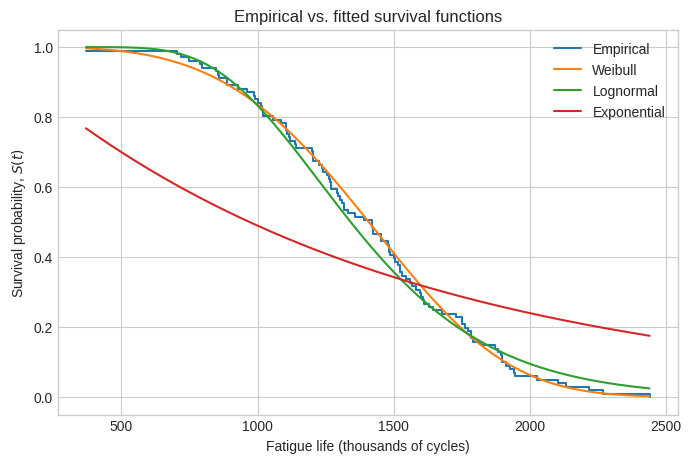

Max |S_Weibull - S_lognormal| = 0.0644 at t ≈ 1365.7 thousand cycles


In [25]:
# YOUR CODE HERE
print("=== Weibull ===")
print(f"shape k = {weibull_shape_hat:.4f}")
print(f"scale lambda = {weibull_scale_hat:.4f} (thousand cycles)")
print(f"mean   = {weibull_model.mean():.4f}")
print(f"median = {weibull_model.median():.4f}")
print(f"P(1000<T<1800) = {weibull_model.cdf(1800)-weibull_model.cdf(1000):.4f}")

print("\n=== Lognormal ===")
print(f"sigma_L = {lognormal_shape_hat:.4f}")
print(f"mu_L = {lognormal_mu_hat:.4f}")
print(f"eta (scale) = {lognormal_scale_hat:.4f} (thousand cycles)")
print(f"mean   = {lognormal_model.mean():.4f}")
print(f"median = {lognormal_model.median():.4f}")
print(f"P(1000<T<1800) = {lognormal_model.cdf(1800)-lognormal_model.cdf(1000):.4f}")

print("\n=== Exponential ===")
print(f"beta (scale/mean) = {exponential_scale_hat:.4f} (thousand cycles)")
print(f"mean   = {exponential_model.mean():.4f}")
print(f"median = {exponential_model.median():.4f}")
print(f"P(1000<T<1800) = {exponential_model.cdf(1800)-exponential_model.cdf(1000):.4f}")


fig, ax = plt.subplots(figsize=(8, 5))
ax.step(grid, S_hat, where="post", label="Empirical")

ax.plot(grid, weibull_model.sf(grid), label="Weibull")
ax.plot(grid, lognormal_model.sf(grid), label="Lognormal")
ax.plot(grid, exponential_model.sf(grid), label="Exponential")

ax.set_xlabel("Fatigue life (thousands of cycles)")
ax.set_ylabel(r"Survival probability, $S(t)$")
ax.set_title("Empirical vs. fitted survival functions")
ax.legend()
plt.show()


grid_new = np.linspace(0, 2600,100)
diff = np.abs(weibull_model.sf(grid_new) - lognormal_model.sf(grid_new))
max_diff = np.max(diff)
indx = np.argmax(diff)
t_at_max = grid_new[indx]
print(f"Max |S_Weibull - S_lognormal| = {max_diff:.4f} at t ≈ {t_at_max:.1f} thousand cycles")

**Interpretation from the plots**

 The Weibull and lognormal survival curves both track the empirical step function closely across the entire range of observed fatigue lives, showing no visible systematic deviation. The exponential model, however, is clearly inconsistent with the data: it predicts a survival probability around 0.77 already at the smallest observed lifetimes (far too low — real specimens rarely fail that early), and it decays far too slowly through the middle and upper range, remaining well above the empirical curve for $t > 1600$. This mismatch reflects the exponential distribution's fixed right-skewed shape (mean far exceeds median), which cannot reproduce the roughly symmetric survival curve seen in the fatigue-life data.

 Max |S_Weibull - S_lognormal| = 0.0644 at t ≈ 1365.7 thousand cycles

 Difference is at $t \approx 1365.7$ thousand cycles close to the median fatigue life, where both curves are descending most steeply. Away from this region the two curves nearly coincide, so despite differing functional forms, the Weibull and lognormal models make very similar predictions across almost the entire range of fatigue lives; only in the middle of the distribution do they disagree by more than a few percentage points.

### 2.3 Turning a model check into a uniformity check (20 points)

A CDF provides a useful model diagnostic. Suppose $T$ truly has a continuous
CDF $F$ that is strictly increasing over the values $T$ can take. Let
$F^{-1}$ denote its inverse, also called its quantile function, and define
$U=F(T)$. For $0<u<1$,

$$
P(U\leq u)
=P\!\left(T\leq F^{-1}(u)\right)
=F\!\left(F^{-1}(u)\right)
=u.
$$

The endpoint cases $u=0$ and $u=1$ follow directly. Thus, $U$ follows the
[uniform distribution on $[0,1]$](https://predictivesciencelab.github.io/data-analytics-se/lecture04/hands-on-04.1.html). This calculation is called the
**probability-integral transform**.

For each fitted model, transform every observed fatigue life using its fitted CDF.
If a model describes the data well, the transformed values should be spread
approximately uniformly between zero and one. We will make a descriptive
comparison; the parameters were fitted using the same observations, so the
calculation below is not a formal hypothesis test. Fitting on these observations
tends to make the discrepancy smaller, so we use it only as a descriptive
distance and do not compare it with a standard cutoff.

1. **CDF implementation (8 points).** Implement the Weibull, lognormal, and
   exponential CDF formulas yourself. Each function must accept a NumPy array,
   return an array of the same shape, and include a docstring following the
   course convention. You may call `stats.norm.cdf` only for the standard
   Gaussian CDF $\Phi$ appearing inside the lognormal CDF. Verify your
   implementations against the supplied fitted SciPy objects at
   $t=-100,500,1000,1500,2000$, and report the largest absolute discrepancy
   for each model.
2. **Transformed histograms (6 points).** Transform the 101 observations with
   each fitted CDF. Make three count histograms with ten equal-width bins on
   $[0,1]$. Under exact uniformity, the expected count is
   $101/10=10.1$ observations per bin.
3. **Descriptive comparison (6 points).** Apply the supplied
   `uniform_discrepancy` function. It returns the maximum
   vertical distance $D$ between the empirical CDF of the transformed values
   and the uniform CDF. A smaller $D$ indicates closer descriptive agreement.
   Compare the three models, identify any model that is clearly inconsistent
   with the data, and state which models you would carry into the replacement
   calculation. Do not attach a $p$-value or declare any model true.

Max discrepancy (Weibull):    2.78e-17
Max discrepancy (Lognormal):  1.67e-16
Max discrepancy (Exponential):5.55e-17


/tmp/ipykernel_4673/3139868752.py:11: RuntimeWarning: invalid value encountered in power
  result = np.where(t < 0, 0, 1 - np.exp(-(t / scale) ** shape))
/tmp/ipykernel_4673/3139868752.py:22: RuntimeWarning: invalid value encountered in log
  result = np.where(t <= 0, 0, stats.norm.cdf((np.log(t) - mu) / sigma))


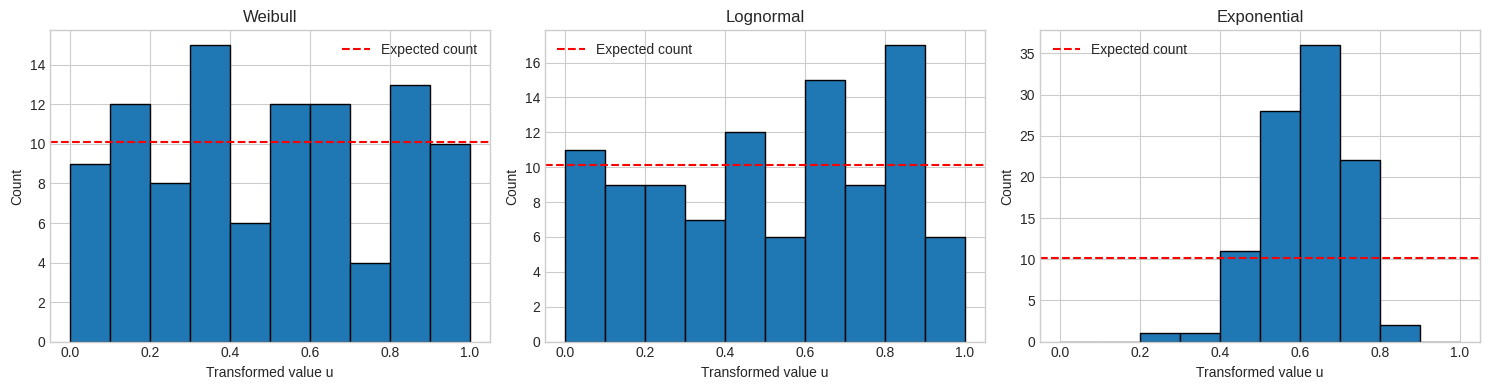

D (Weibull):     0.0551
D (Lognormal):   0.0747
D (Exponential): 0.3931


In [26]:
# 1. CDF implementation
def weibull_cdf(t, shape, scale):
    """Evaluate the Weibull CDF at each point in t.

    Arguments:
    t     -- array of lifetime values at which to evaluate the CDF (same units as scale)
    shape -- the Weibull shape parameter k (dimensionless, k > 0)
    scale -- the Weibull scale parameter lambda (same units as t, lambda > 0)
    """
    t = np.asarray(t, dtype=float)
    result = np.where(t < 0, 0, 1 - np.exp(-(t / scale) ** shape))
    return result
def lognormal_cdf(t, mu, sigma):
    """Evaluate the lognormal CDF at each point in t.

    Arguments:
    t     -- array of lifetime values at which to evaluate the CDF (thousands of cycles)
    mu    -- mu_L, the mean of log T
    sigma -- sigma_L, the standard deviation of log T (sigma > 0)
    """
    t = np.asarray(t, dtype=float)
    result = np.where(t <= 0, 0, stats.norm.cdf((np.log(t) - mu) / sigma))
    return result

def exponential_cdf(t, scale):
    """Evaluate the exponential CDF at each point in t.

    Arguments:
    t      -- array of lifetime values at which to evaluate the CDF (same units as scale)
    scale  -- the exponential scale parameter beta (same units as t, beta > 0)
    """
    t = np.asarray(t, dtype=float)
    result = np.where(t < 0, 0, 1 - np.exp(-t / scale))
    return result


t_check = np.array([-100, 500, 1000, 1500, 2000])

weibull_diff = np.abs(
    weibull_cdf(t_check, weibull_shape_hat, weibull_scale_hat) - weibull_model.cdf(t_check)
)
lognormal_diff = np.abs(
    lognormal_cdf(t_check, lognormal_mu_hat, lognormal_shape_hat) - lognormal_model.cdf(t_check)
)
exponential_diff = np.abs(
    exponential_cdf(t_check, exponential_scale_hat) - exponential_model.cdf(t_check)
)

print(f"Max discrepancy (Weibull):    {np.max(weibull_diff):.2e}")
print(f"Max discrepancy (Lognormal):  {np.max(lognormal_diff):.2e}")
print(f"Max discrepancy (Exponential):{np.max(exponential_diff):.2e}")



# 2.Transformed histograms
u_weibull = weibull_cdf(fatigue_life, weibull_shape_hat, weibull_scale_hat)
u_lognormal = lognormal_cdf(fatigue_life, lognormal_mu_hat, lognormal_shape_hat)
u_exponential = exponential_cdf(fatigue_life, exponential_scale_hat)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, u, name in zip(axes, [u_weibull, u_lognormal, u_exponential],
                       ["Weibull", "Lognormal", "Exponential"]):
    ax.hist(u, bins=10, range=(0, 1), edgecolor="black")
    ax.axhline(101/10, color="red", linestyle="--", label="Expected count")
    ax.set_title(name)
    ax.set_xlabel("Transformed value u")
    ax.set_ylabel("Count")
    ax.legend()
plt.tight_layout()
plt.show()


# 3.uniform_discrepancy
D_weibull = uniform_discrepancy(u_weibull)
D_lognormal = uniform_discrepancy(u_lognormal)
D_exponential = uniform_discrepancy(u_exponential)
print(f"D (Weibull):     {D_weibull:.4f}")
print(f"D (Lognormal):   {D_lognormal:.4f}")
print(f"D (Exponential): {D_exponential:.4f}")



**1.CDF implementation**

Max discrepancy (Weibull):    2.78e-17
Max discrepancy (Lognormal):  1.67e-16
Max discrepancy (Exponential):5.55e-17

**2. Transformed histograms**

The Weibull and lognormal transformed histograms are both reasonably flat, with bin counts fluctuating around the expected value of 10.1 without any strong systematic pattern consistent with the transformed values being approximately uniform on [0,1], which supports both models as reasonable descriptions of the fatigue-life data. The exponential model's histogram, in contrast, is clearly non-uniform: nearly all 101 transformed values fall between 0.4 and 0.8, with almost no observations near 0 or 1. This concentration confirms that the exponential model is a poor fit, it systematically misjudges where observations should fall relative to its own CDF.

**3. uniform_discrepancy**

The Kolmogorov-style discrepancy $D$ between each model's transformed values and the uniform distribution is smallest for the Weibull model ($D=0.0551$), somewhat larger for the lognormal model ($D=0.0747$), and dramatically larger for the exponential model ($D=0.3931$) — more than five times the lognormal value and over seven times the Weibull value. This is consistent with the transformed histograms and the survival-function overlay: the exponential model is clearly inconsistent with the fatigue-life data, while the Weibull and lognormal models both show reasonably close, and similar, descriptive agreement with the data. Since this diagnostic is computed on the same data used to fit the parameters, it is not a formal hypothesis test and we do not compare $D$ to a rejection threshold — it only supports the qualitative ranking already suggested by the earlier plots. Based on this evidence, we would carry the **Weibull** and **lognormal** models forward into the replacement calculation and set aside the exponential model.


### 2.4 A tail-sensitive replacement decision (15 points)

A design team provisionally treats the specimen lifetimes as representative of a
component operating under the same loading condition. The proposed policy
replaces the component after 300 thousand cycles. Within a fitted model, the
policy meets its target when the probability of rupture before replacement is
at most $0.001$, or $0.1\%$. Based on your Part 2.3 comparison, use the two
models with the smaller $D$ scores as the decision candidates. Analyze the
remaining model separately in item 3 below.

1. **Proposed policy (4 points).** Calculate the predicted risk at 300 thousand
   cycles under each decision candidate, and decide whether the proposal
   passes under each model.
2. **Model-based ages (4 points).** Calculate the latest replacement age
   satisfying the target under each decision candidate. If the policy must
   satisfy both candidates, state the resulting replacement age. Compare both
   model-based ages with the smallest observed fatigue life.
3. **The remaining model (3 points).** Calculate the remaining model's
   predicted risk at 300 thousand cycles and its latest age satisfying the
   target. Explain how the model check in Part 2.3 should affect the use of
   these numbers in the policy decision.
4. **Strength of the conclusion (4 points).** State whether the calculations
   provide a 99.9% reliability guarantee. In your explanation, compare the
   target probability $0.001$ with $1/101$, the empirical-probability change
   contributed by one observation.

In [27]:
# YOUR CODE HERE
risk_weibull_300 = weibull_model.cdf(300)
risk_lognormal_300 = lognormal_model.cdf(300)

print(f"Weibull risk at t=300:   {risk_weibull_300:.6f}  {'PASS' if risk_weibull_300 <= 0.001 else 'FAIL'}")
print(f"Lognormal risk at t=300: {risk_lognormal_300:.6f}  {'PASS' if risk_lognormal_300 <= 0.001 else 'FAIL'}")

age_weibull = weibull_model.ppf(0.001)
age_lognormal = lognormal_model.ppf(0.001)

print(f"Weibull age satisfying target:   {age_weibull:.4f} thousand cycles")
print(f"Lognormal age satisfying target: {age_lognormal:.4f} thousand cycles")

risk_exponential_300 = exponential_model.cdf(300)
print(f"Exponential risk at t=300:   {risk_exponential_300:.6f}  {'PASS' if risk_exponential_300 <= 0.001 else 'FAIL'}")
age_exponential = exponential_model.ppf(0.001)
print(f"Exponential age satisfying target:   {age_exponential:.4f} thousand cycles")

Weibull risk at t=300:   0.001547  FAIL
Lognormal risk at t=300: 0.000000  PASS
Weibull age satisfying target:   268.5663 thousand cycles
Lognormal age satisfying target: 523.8870 thousand cycles
Exponential risk at t=300:   0.192770  FAIL
Exponential age satisfying target:   1.4016 thousand cycles


**Part 1 — Proposed policy.**

The Weibull model predicts a rupture probability of 0.001547 at t=300, which exceeds the 0.001 target — the proposal fails under Weibull. The lognormal model predicts an essentially negligible rupture probability (~0.000000) at t=300, comfortably passing the target. The two models that both fit the bulk of the data well nonetheless disagree sharply on this specific tail question, illustrating that good overall fit does not guarantee agreement in the extreme tail.

**Part 2 — Model-based ages.**

The latest replacement age meeting the 0.001 target is 268.57 thousand cycles under Weibull and 523.89 thousand cycles under lognormal — nearly a factor of two apart. If the policy must satisfy both models simultaneously, the binding (more conservative) constraint is the smaller value, 268.57 thousand cycles. Notably, both model-based ages fall below the smallest observed fatigue life in the dataset (370 thousand cycles) — the policy's target region has no direct empirical support and relies entirely on parametric extrapolation into the tail below all observed data.

**Part 3 — The remaining model.**

 The exponential model predicts a rupture probability of 0.192770 at t=300 — nearly 100 times larger than the Weibull estimate and far above the 0.001 target — and its latest replacement age meeting the target is only 1.4 thousand cycles, roughly 200 times more conservative than the Weibull-based age. These numbers should not be used in the policy decision: Part 2.3 showed the exponential model is clearly inconsistent with the data (D=0.3931, versus 0.055-0.075 for the other two models), specifically because it drastically overstates the probability of very early failure — exactly the regime this tail-sensitive policy question depends on. Its extreme numbers here are an artifact of a poorly fitting model, not evidence about the component's true early-life risk.

 **Part 4 — Strength of the conclusion.**

  No, these calculations do not provide a genuine 99.9% reliability guarantee. The target risk of 0.001 is roughly ten times smaller than 1/101 ≈ 0.0099 — the amount by which the *empirical* probability estimate would shift if a single additional observation were added to or removed from the dataset. With only 101 specimens, the data simply cannot resolve differences at the 0.001 level directly: no observed failure occurred anywhere near this probability level, since the smallest recorded fatigue life (370 thousand cycles) already lies well above both model-based replacement ages. Everything below that point is pure parametric extrapolation, dictated entirely by the assumed mathematical shape of whichever model is used — which is precisely why Weibull and lognormal, despite fitting the bulk of the data almost identically well, disagree by nearly a factor of two on the replacement age, and why Weibull technically fails the target while lognormal comfortably passes it. A conclusion this sensitive to model choice, in a region with no supporting data, cannot be treated as a reliable 99.9% guarantee — it is a model-dependent estimate whose uncertainty is much larger than the quantity it is being used to bound.

### 2.5 Scope of the conclusion (10 points)

In no more than four sentences, state one specific limitation of using these
specimen experiments to set a replacement policy for an actual component.
Identify additional data or experimental information that would address the
limitation. Your answer must refer to the experimental setting or the
model-based tail calculation rather than merely saying that more data are
needed.

These specimens were all tested at a single fixed stress of 21,000 psi, so the fitted models, and the Part 2.4 replacement age, which extrapolates the CDF below the smallest observed life of 370 thousand cycles say nothing about fatigue behavior under the component's actual service loads or in the unobserved low-cycle region. Addressing this would require fatigue tests run directly at the component's actual service stress levels and specimens deliberately tested to early failure, so the low-cycle tail the policy depends on is backed by observed data rather than model shape alone.